In [157]:
#!/usr/bin/env python3
import os
import re
import sys
import collections
import argparse
import itertools 
import scipy
import matplotlib
import glob
from tqdm import tqdm

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import numpy as np
import pandas as pd

from Bio import SeqIO

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from multiprocessing import Pool
from collections import defaultdict
from scipy import sparse
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import hypergeom

import scipy.io as io

In [158]:
!ls /project/GCRB/Hon_lab/s223695/Data_project/reference

Dfam_3_3.embl  Dfam_curatedonly.h5  RMRBSeqs.embl  hg19  hg38  hg38_ucsc


In [181]:
dfam_file = "/project/GCRB/Hon_lab/s223695/Data_project/reference/Dfam_3_3.embl"
dfam_lib_file = "/project/GCRB/Hon_lab/s223695/Data_project/reference/Dfam-RepeatMasker.lib"

In [219]:
dfam_lib_iter = SeqIO.parse(dfam_lib_file , "fasta")
record_sep = []

while True:
    try:
        record = next(dfam_lib_iter)
    
    except StopIteration:
        print("end")
        break
    desc = record.description
    desc_split = re.split("[# ]+",desc)
    
    species_index = []
    for i,item in enumerate(desc_split):
        if item.startswith("@"):
            species_index.append(i)
    species_name = [desc_split[i][1:] for i in species_index]
    if len(species_name)>1:
        print(species_name)
    record_sep.append([desc_split[0],desc_split[1],species_name])

['Metatheria', 'Eutheria']
['Metatheria', 'Eutheria']
['Rodentia', 'Strepsirrhini', 'Haplorrhini']
['Metatheria', 'Eutheria']
['Primates', 'Glires']
['Scandentia', 'Primates']
['Metatheria', 'Eutheria']
['Primates', 'Carnivora', 'Artiodactyla']
['Scandentia', 'Primates']
['Metatheria', 'Xenarthra', 'Primates', 'Rodentia', 'Carnivora', 'Artiodactyla', 'Afrotheria']
['Sauropsida', 'Mammalia']
['Monotremata', 'Theria_mammals']
['Drosophila_mauritiana', 'Drosophila_melanogaster', 'Drosophila_sechellia', 'Drosophila_simulans']
['Danio', 'Danio_rerio']
['Danio', 'Danio_rerio']
['Danio', 'Danio_rerio']
end


In [233]:
dfam_table = pd.DataFrame(record_sep,columns=["name","class","organism"])
dfam_table.to_csv("./dfam_table.csv")

### Slice repetitive elements and zinc finger protein

In [139]:
RE_annotation_df = pd.read_csv('/project/GCRB/Hon_lab/s159317/IGVF/scTE_mapping/CM.TF-Perturb-Seq/temp/rmsk.txt', sep='\t', 
                               names=['1', '2', '3', '4', '5', 'chr', 'start', 'end', 'pos', 'strand', 'name', 'cate', 'names', '6', '7', '8', '9'])

In [140]:
RE_annotation_df.head()

,1,2,3,4,5,chr,start,end,pos,strand,name,cate,names,6,7,8,9
0,585,463,13,6,17,chr1,10000,10468,-248945954,+,(TAACCC)n,Simple_repeat,Simple_repeat,1,471,0,1
1,585,3612,114,215,13,chr1,10468,11447,-248944975,-,TAR1,Satellite,telo,-399,1712,483,2
2,585,484,251,132,0,chr1,11504,11675,-248944747,-,L1MC5a,LINE,L1,-2382,395,199,3
3,585,239,294,19,10,chr1,11677,11780,-248944642,-,MER5B,DNA,hAT-Charlie,-74,104,1,4
4,585,318,230,37,0,chr1,15264,15355,-248941067,-,MIR3,SINE,MIR,-119,143,49,5


In [283]:
np.unique(RE_annotation_df["cate"])

array(['DNA', 'DNA?', 'LINE', 'LTR', 'LTR?', 'Low_complexity', 'RC',
       'RC?', 'RNA', 'Retroposon', 'SINE', 'SINE?', 'Satellite',
       'Simple_repeat', 'Unknown', 'rRNA', 'scRNA', 'snRNA', 'srpRNA',
       'tRNA'], dtype=object)

In [288]:
val_repeat_category = ['DNA', 'DNA?', 'LINE', 'LTR', 'LTR?',
                       'RC','RC?','Retroposon', 'SINE', 'SINE?']

In [289]:
RE_name_all = np.unique(RE_annotation_df[np.isin(RE_annotation_df["cate"],val_repeat_category)]["name"])

In [141]:
RE_family_dict = dict(RE_annotation_df[["name","cate"]].values)

### Load DE table

In [82]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [78]:
GLBOAL_HITS = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/pySpade/unfiltered_global_df.csv'
FILE_DIR = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/pySpade/'

In [79]:
df_column_list = [
    'idx', 'gene_names', 'chromosome', 'pos', 'strand', 
    'color_idx', 'chr_idx', 
    'region', 'num_cell', 'bin',
    'log(pval)-hypergeom', 'fc', 'Significance_score', 'fc_by_rand_dist_cpm', 'pval-empirical', 'cpm_perturb', 'cpm_bg']

In [80]:
global_df = pd.read_csv(GLBOAL_HITS)[df_column_list]

In [83]:
global_df['TF_annotation'] = [annot_dict[i] for i in global_df['region']]

In [84]:
global_df_TE = global_df.loc[global_df["gene_names"].isin(RE_annotation_df["name"])]

### Process global df

In [85]:
CUTOFF_EXP = 0.05
CUTOFF_FC = 0.2
CUTOFF_SIG = -14

In [87]:
#Load expressed genes 
gene_seq = np.load(FILE_DIR + 'Trans_genome_seq.npy', allow_pickle=True)
express_level = np.load(FILE_DIR + 'Perc_cell_expr.npy')
express_idx = np.where(express_level > CUTOFF_EXP)[0]

In [88]:
express_df = global_df[global_df['gene_names'].isin(gene_seq[express_idx]) &
                       ((global_df['fc_by_rand_dist_cpm'] > (1+CUTOFF_FC)) | (global_df['fc_by_rand_dist_cpm'] < (1-CUTOFF_FC))) &
                       (global_df['Significance_score'] < CUTOFF_SIG) &
                       (global_df['pval-empirical'] < 0.001) &
                       (global_df['log(pval)-hypergeom'] < -3)].copy()

In [89]:
zinc_fing_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/zinc_finger_gene_list.txt', sep='\t')

In [90]:
subset_express_df = express_df[(express_df['gene_names'].isin(RE_annotation_df['name'])) &
                               (express_df['TF_annotation'].isin(list(zinc_fing_df['Approved symbol'])))
                              ]
express_df_TE = express_df[(express_df['gene_names'].isin(RE_annotation_df['name']))
                       ]

In [91]:
subset_express_df.shape

(59, 18)

In [92]:
subset_express_df_sub = subset_express_df.loc[:,["TF_annotation","gene_names",
                         "Significance_score","fc_by_rand_dist_cpm"]].copy()

# correct signs based on fold change
subset_express_df_sub["Significance_score_correct"] = subset_express_df_sub.apply(
    lambda x:x["Significance_score"] *(((x["fc_by_rand_dist_cpm"]<1)*2-1)),axis=1)

subset_express_df_sub = \
    subset_express_df_sub.loc[:,["TF_annotation","gene_names","Significance_score_correct"]]

In [93]:
express_df_sub = express_df_TE.loc[:,["TF_annotation","gene_names",
                         "Significance_score","fc_by_rand_dist_cpm"]].copy()

# correct signs based on fold change
express_df_sub["Significance_score_correct"] = express_df_sub.apply(
    lambda x:x["Significance_score"] *(((x["fc_by_rand_dist_cpm"]<1)*2-1)),axis=1)

express_df_sub = \
    express_df_sub.loc[:,["TF_annotation","gene_names","Significance_score_correct"]]

In [94]:
subset_express_df.shape

(59, 18)

In [95]:
subset_express_df_pivot = subset_express_df_sub.pivot_table(index='gene_names',columns='TF_annotation',values='Significance_score_correct')
subset_express_df_pivot = subset_express_df_pivot.fillna(0)

express_df_pivot = express_df_sub.pivot_table(index='gene_names',columns='TF_annotation',values='Significance_score_correct')
express_df_pivot = express_df_pivot.fillna(0)

In [236]:
dfam_table

,name,class,organism
0,MIR,SINE/MIR,[Mammalia]
1,AluY,SINE/Alu,[Catarrhini]
2,AluSc,SINE/Alu,[Simiiformes]
3,Tigger3a,DNA/TcMar-Tigger,[Primates]
4,THE1A,LTR/ERVL-MaLR,[Haplorrhini]
...,...,...,...
25310,DF003450332,Unknown,[Heligmosomoides_polygyrus]
25311,DF003450333,DNA/TcMar-Mariner,[Heligmosomoides_polygyrus]
25312,DF003450334,Unknown,[Heligmosomoides_polygyrus]
25313,DF003450335,PLE/Naiad,[Heligmosomoides_polygyrus]


In [252]:
def get_te_origin(te_name):
    if te_name in dfam_table["name"].values:
        return dfam_table[dfam_table["name"]==te_name]["organism"].values[0]
    # use TE name for "-int" type naming
    if "-int" in te_name:
        te_name = te_name.split("-int")[0]
        
        if te_name in dfam_table["name"].values:
            return dfam_table[dfam_table["name"]==te_name]["organism"].values[0]
        else:
            return None
    #For LINE element, te name in library is like "L1_orf2" 
    else:
        for dfam_name in dfam_table["name"].values:
            if "_" in dfam_name:
                if te_name == dfam_name.split("_")[0]:
                    return dfam_table[dfam_table["name"]==dfam_name]["organism"].values[0]
    return None
    

In [306]:
RE_name_all_origin = [get_te_origin(i) for i in RE_name_all]
RE_name_all_origin_dict = {}
for i,origin_name in enumerate(RE_name_all_origin):
    if origin_name == None:
        continue
    if len(origin_name)>1:
        continue
    RE_name_all_origin_dict[RE_name_all[i]] = origin_name[0]


In [320]:
all_RE_df = \
    pd.DataFrame(np.unique(list(RE_name_all_origin_dict.values()),return_counts=True)).T
all_RE_df.columns = ["name","count_all"]

In [332]:
all_RE_df.head()

,name,count_all
0,Amniota,64
1,Boreoeutheria,41
2,Catarrhini,83
3,Euarchontoglires,45
4,Euteleostomi,1


In [321]:
express_df_sub["origin"] = [get_te_origin(i) for i in express_df_sub["gene_names"]]

In [322]:
num_tax = express_df_sub["origin"].apply(lambda x: len(x))

In [323]:
express_df_sub_single = express_df_sub[num_tax==1].copy()
express_df_sub_single["origin"] = express_df_sub_single["origin"].apply(lambda x:x[0])

In [324]:
regulated_RE_df = pd.DataFrame(np.unique(express_df_sub_single["origin"],return_counts=True)).T
regulated_RE_df.columns = ["name","count_reg"]

In [333]:
regulated_RE_df.head()

,name,count_reg
0,Amniota,3
1,Boreoeutheria,4
2,Catarrhini,14
3,Euarchontoglires,2
4,Eutheria,45


In [349]:
merged_df = pd.merge(all_RE_df,regulated_RE_df, on='name', how='outer')
merged_df = merged_df.fillna(0)

/tmp/ipykernel_3901/538094429.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df = merged_df.fillna(0)


In [350]:
merged_df["percent_all"] = merged_df["count_all"]/np.sum(merged_df["count_all"])*100
merged_df["percent_reg"] = merged_df["count_reg"]/np.sum(merged_df["count_reg"])*100

merged_df = merged_df.set_index("name")

In [351]:
evo_sort_order = [
    'Euteleostomi',
    'Tetrapoda',
    'Amniota',
    'Mammalia',
    'Theria_mammals',
    'Eutheria',
    'Boreoeutheria',
    'Euarchontoglires',
    'Primates',
    'Haplorrhini',
    'Simiiformes',
    'Catarrhini',
    'Hominoidea',
    'Hominidae',
    'Homininae',
    'Homo_sapiens'
]

In [362]:
merged_df = merged_df.loc[evo_sort_order]

In [363]:
total_count = np.sum(merged_df["count_all"])
reg_count = np.sum(merged_df["count_reg"])
pval_list = []

for name in merged_df.index:
    count_all,count_reg = merged_df.loc[name,["count_all","count_reg"]]
    pval = hypergeom.cdf(count_reg,total_count,reg_count,count_all)
    pval_list.append(min(pval,1-pval))

In [364]:
rank_arr = np.argsort(np.argsort(pval_list))+1
prb_list_adj = []

for i,pval in enumerate(pval_list):
    adj_prb = pval*max(rank_arr)/rank_arr[i]
    prb_list_adj.append(adj_prb)
    
for i,name in enumerate(merged_df.index):
    print(name,prb_list_adj[i])

Euteleostomi 0.22009105880073618
Tetrapoda 0.2175159312273621
Amniota 0.10238523693043147
Mammalia 0.19077253452134676
Theria_mammals 0.3307189061847901
Eutheria 0.41301032463390025
Boreoeutheria 0.4117129396156681
Euarchontoglires 0.17879605667089316
Primates 0.020364748945762002
Haplorrhini 0.0008606861676465627
Simiiformes 0.002107168294346984
Catarrhini 0.17500125861606872
Hominoidea 0.3390841900017082
Hominidae 0.0615756913773291
Homininae 0.3463296581667299
Homo_sapiens 0.33759389440331805


#### Plot data

In [375]:
merged_df_plot = merged_df.loc[:,["percent_all","percent_reg"]].melt(ignore_index=False)

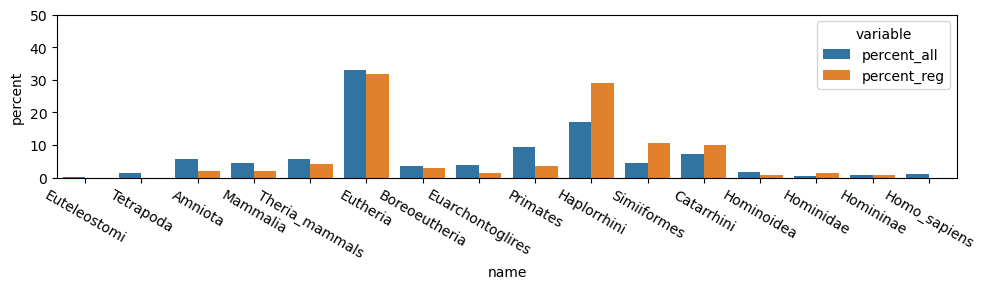

In [396]:
fig,ax=plt.subplots(figsize=(10,3))
sns.barplot(merged_df_plot,x="name",y="value",hue="variable")
plt.ylim(0,50)

plt.xticks(fontsize=10,rotation=-30)
plt.ylabel("percent")
plt.tight_layout()

plt.savefig("./figure/evolution_age.pdf")

In [354]:
express_df_sub_single[express_df_sub_single["origin"]=="Catarrhini"]

,TF_annotation,gene_names,Significance_score_correct,origin
3781585,TADA2B,HERVIP10FH-int,14.600989,Catarrhini
7965882,TCF7,HERVH-int,15.146103,Catarrhini
10311364,MIXL1,HERV30-int,15.148094,Catarrhini
10681897,XRCC6,HERV30-int,14.658778,Catarrhini
12089677,GLI3,MER11A,14.145126,Catarrhini
14733093,ZNF649,HERV9NC-int,14.393882,Catarrhini
14758600,CHAMP1,LTR10C,15.499049,Catarrhini
18021492,TBX20,HERV30-int,22.614867,Catarrhini
18022781,TBX20,LTR30,18.979673,Catarrhini
18842689,GATAD1,LTR30,17.688797,Catarrhini
